# Air Quality Prediction
### Regression (predict AQI) + Classification (predict AQI Category)


REGRESSION PIPELINE:

  1. Load → Clean → Feature Engineer
  2. Train/Test Split  (FIRST, before anything else)
  3. Baselines
  4. Define all candidate models

     └─ Linear Regression wrapped in Pipeline(StandardScaler)

     └─ Tree models (RF, XGBoost, LightGBM, Stacking) — no scaler needed
     
  5. CV all models     (find the winner by data, not assumption)
  6. GridSearchCV      (tune ONLY the CV winner)
  7. Diagnostics on held-out test set
  8. SHAP

CLASSIFICATION PIPELINE:

  1.  Same split from regression 
  3.  SMOTE on train only
  4.  Baselines
  5.  Define all candidate models (all tree-based — no scaler needed)
  6.  CV all models     (find the winner)
  7.  GridSearchCV      (tune ONLY the CV winner)
  8.  Soft Voting Ensemble (built around tuned winner)
  9.  Diagnostics on held-out test set
 10.  Final Summary


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, KFold
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    VotingClassifier, StackingRegressor
)
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    r2_score, mean_absolute_error
)
from sklearn.dummy import DummyClassifier, DummyRegressor
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap

print('All libraries loaded successfully')

All libraries loaded successfully


## 2. Load Data

In [2]:
df = pd.read_csv('air_quality_data.csv')

BASE_FEATURES = ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3']

print('Shape:', df.shape)
print(df.isnull().sum())
print('\nCities:', df['City'].unique())

Shape: (3349, 9)
City          0
Date          0
PM2.5         6
PM10          6
NO2           6
SO2           6
O3            6
AQI           6
AQI_Bucket    6
dtype: int64

Cities: ['Delhi' 'Kolkata' 'Mumbai' 'Chandigarh' 'Bengaluru']


## 3. Clean Data

In [3]:
for col in BASE_FEATURES + ['AQI']:
    df[col].fillna(df[col].mean(), inplace=True)

def aqi_to_bucket(aqi):
    if aqi <= 50:    return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

df.loc[df['AQI_Bucket'].isnull(), 'AQI_Bucket'] = (
    df.loc[df['AQI_Bucket'].isnull(), 'AQI'].apply(aqi_to_bucket)
)

# Encode City 
le_city = LabelEncoder()
df['City_encoded'] = le_city.fit_transform(df['City'])
print('City encoding:', dict(zip(le_city.classes_, le_city.transform(le_city.classes_))))

df = df.drop(columns=['City', 'Date'])

print('\nShape after cleaning:', df.shape)
print(df.isnull().sum())
df.head()

City encoding: {'Bengaluru': np.int64(0), 'Chandigarh': np.int64(1), 'Delhi': np.int64(2), 'Kolkata': np.int64(3), 'Mumbai': np.int64(4)}

Shape after cleaning: (3349, 8)
PM2.5           0
PM10            0
NO2             0
SO2             0
O3              0
AQI             0
AQI_Bucket      0
City_encoded    0
dtype: int64


,PM2.5,PM10,NO2,SO2,O3,AQI,AQI_Bucket,City_encoded
0,230.50,355.43,61.28,24.28,75.14,370.0,Very Poor,2
1,191.47,308.74,54.37,22.47,64.80,365.0,Very Poor,2
2,177.71,309.85,52.51,19.12,59.73,352.0,Very Poor,2
3,133.56,231.04,46.86,19.06,54.00,278.0,Poor,2
4,235.06,353.55,47.86,14.48,64.10,350.0,Very Poor,2


## 4. Feature Engineering

In [4]:
df['PM_total']         = df['PM2.5'] + df['PM10']
df['gas_total']        = df['NO2'] + df['SO2'] + df['O3']
df['PM_gas_ratio']     = df['PM_total'] / (df['gas_total'] + 1)
df['PM2.5_PM10_ratio'] = df['PM2.5'] / (df['PM10'] + 1)
df['NO2_O3_ratio']     = df['NO2'] / (df['O3'] + 1)

ENGINEERED   = ['PM_total', 'gas_total', 'PM_gas_ratio', 'PM2.5_PM10_ratio', 'NO2_O3_ratio']
ALL_FEATURES = BASE_FEATURES + ENGINEERED + ['City_encoded']

print(f'Original features  : {len(BASE_FEATURES)}')
print(f'Engineered features: {len(ENGINEERED)}')
print(f'City encoded       : 1')
print(f'Total features     : {len(ALL_FEATURES)}')

Original features  : 5
Engineered features: 5
City encoded       : 1
Total features     : 11


## 5. EDA

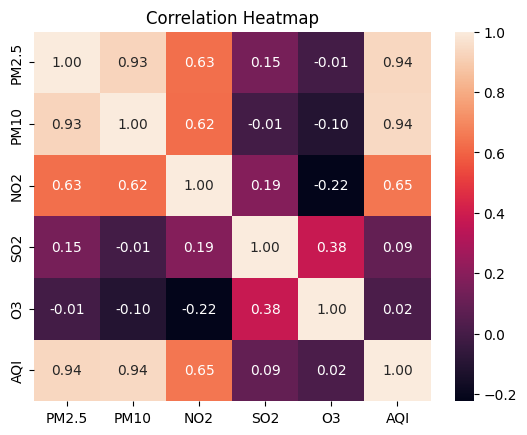

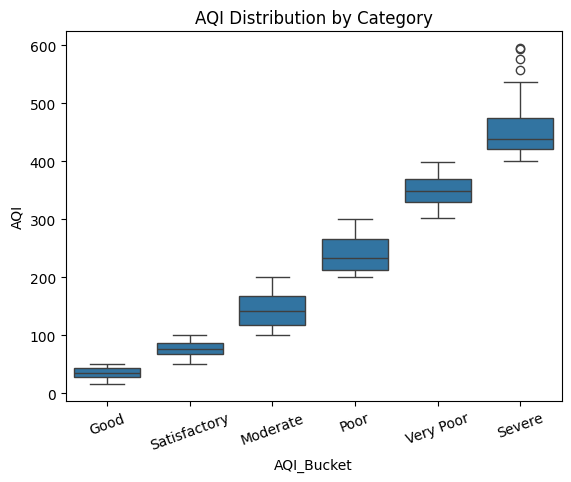

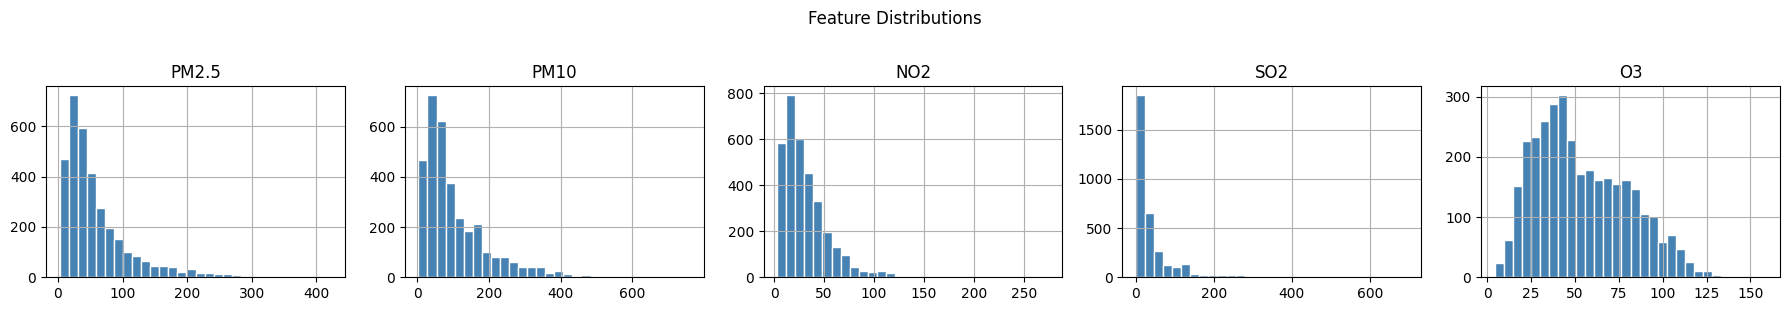

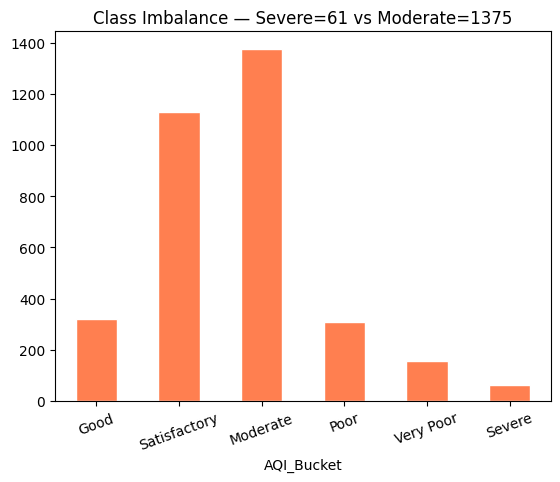

In [5]:
ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

sns.heatmap(df[BASE_FEATURES + ['AQI']].corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

sns.boxplot(data=df, x='AQI_Bucket', y='AQI', order=ORDER)
plt.title('AQI Distribution by Category')
plt.xticks(rotation=20)
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, col in zip(axes, BASE_FEATURES):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

df['AQI_Bucket'].value_counts().reindex(ORDER).plot(
    kind='bar', color='coral', edgecolor='white')
plt.title('Class Imbalance — Severe=61 vs Moderate=1375')
plt.xticks(rotation=20)
plt.show()

## 6. Train/Test Split

**Done first, before SMOTE or any model fitting.**
The test set is locked away and never touched until final evaluation.
No global scaler is applied here — tree models don't need it, and
Linear Regression gets its own scaler inside a Pipeline.

In [6]:
le = LabelEncoder()

X       = df[ALL_FEATURES].copy()
y_reg   = df['AQI']
y_clf   = le.fit_transform(df['AQI_Bucket'])

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print(f'Train : {X_train.shape[0]} rows')
print(f'Test  : {X_test.shape[0]} rows')

Train : 2679 rows
Test  : 670 rows


## 7. SMOTE — Train Only

Applied **after** split, **only** on training data.
Test set stays original and imbalanced — that is the real-world distribution.
No scaling applied here — all classifiers are tree-based and scale-invariant.

In [7]:
sm = SMOTE(random_state=42)
X_train_resampled, y_clf_train_resampled = sm.fit_resample(X_train, y_clf_train)

print('BEFORE SMOTE (train):')
before = pd.Series(y_clf_train).value_counts()
before.index = le.inverse_transform(before.index)
print(before)

print('\nAFTER SMOTE (train only):')
after = pd.Series(y_clf_train_resampled).value_counts()
after.index = le.inverse_transform(after.index)
print(after)

print(f'\nTrain: {len(y_clf_train)} → {len(y_clf_train_resampled)} | Test: {len(y_clf_test)} (unchanged)')

BEFORE SMOTE (train):
Moderate        1100
Satisfactory     902
Good             255
Poor             246
Very Poor        127
Severe            49
Name: count, dtype: int64

AFTER SMOTE (train only):
Moderate        1100
Satisfactory    1100
Severe          1100
Poor            1100
Good            1100
Very Poor       1100
Name: count, dtype: int64

Train: 2679 → 6600 | Test: 670 (unchanged)


## 9. Baselines

In [8]:
dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(X_train, y_reg_train)
dummy_r2 = r2_score(y_reg_test, dummy_reg.predict(X_test))

dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train_resampled, y_clf_train_resampled)
dummy_acc = (dummy_clf.predict(X_test) == y_clf_test).mean()

print(f'Regression Baseline R²  : {dummy_r2:.4f}')
print(f'Classification Baseline : {dummy_acc:.4f}')
print('Your models must beat these ↑')

Regression Baseline R²  : -0.0001
Classification Baseline : 0.0955
Your models must beat these ↑


# REGRESSION PIPELINE
## 10. Define Regression Models

Tree models need no scaling — they are split-threshold based and scale-invariant.
Linear Regression gets its own `Pipeline(StandardScaler → LinearRegression)`.
This way the scaler fits inside each CV fold — methodologically cleaner
than a global scaler applied before CV.

In [9]:
reg_models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),
    # Tree models 
    'Random Forest': RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.05,
        verbosity=0, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=200, learning_rate=0.05,
        verbose=-1, random_state=42),
    'Stacking': StackingRegressor(
        estimators=[
            ('rf',  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
            ('xgb', xgb.XGBRegressor(n_estimators=100, verbosity=0, random_state=42, n_jobs=-1))
        ],
        final_estimator=lgb.LGBMRegressor(
            n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1),
        n_jobs=-1
    )
}

print('Regression candidates:', list(reg_models.keys()))

Regression candidates: ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'Stacking']


## 11. Regression CV — Compare All Models First

**This is the correct order.**
We run all models through 5-fold CV and let the data decide the winner.
Only then do we spend GridSearchCV time on the best one.
Tuning a model that CV already showed is mediocre is a waste.

In [10]:
print('Running Regression Cross-Validation on all models...\n')

cv_reg  = KFold(n_splits=5, shuffle=True, random_state=42)
reg_rows = []

for name, model in reg_models.items():
    scores = cross_val_score(
        model, X_train, y_reg_train,
        cv=cv_reg, scoring='r2', n_jobs=-1
    )
    reg_rows.append({
        'Model'   : name,
        'Mean R²' : round(scores.mean(), 4),
        'Std Dev' : round(scores.std(),  4)
    })
    print(f'{name}: {scores.mean():.4f} (+/- {scores.std():.4f})')

reg_results = pd.DataFrame(reg_rows).sort_values('Mean R²', ascending=False).reset_index(drop=True)

reg_results = pd.concat([
    reg_results,
    pd.DataFrame([{'Model': 'Baseline', 'Mean R²': round(dummy_r2, 4), 'Std Dev': 0.0}])
], ignore_index=True)

print('\nREGRESSION CV RESULTS:')
display(reg_results)

# Pick winner — used in next cell to decide WHAT to tune
best_reg_cv_name = reg_results[~reg_results['Model'].str.contains('Baseline')].iloc[0]['Model']
print(f'\n→ CV Winner: {best_reg_cv_name}  — this model gets GridSearchCV')

Running Regression Cross-Validation on all models...

Linear Regression: 0.9315 (+/- 0.0097)
Random Forest: 0.9657 (+/- 0.0045)
XGBoost: 0.9651 (+/- 0.0078)
LightGBM: 0.9646 (+/- 0.0044)
Stacking: 0.9624 (+/- 0.0068)

REGRESSION CV RESULTS:


/Users/matadasaanvi/Desktop/Air_Quality/air_qty/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/matadasaanvi/Desktop/Air_Quality/air_qty/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/matadasaanvi/Desktop/Air_Quality/air_qty/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/matadasaanvi/Desktop/Air_Quality/air_qty/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/matadasaanvi/Desktop/Air_Quality/air_qty/lib/python3.13/site-packages/sklearn/utils/valid

,Model,Mean R²,Std Dev
0,Random Forest,0.9657,0.0045
1,XGBoost,0.9651,0.0078
2,LightGBM,0.9646,0.0044
3,Stacking,0.9624,0.0068
4,Linear Regression,0.9315,0.0097
5,Baseline,-0.0001,0.0000



→ CV Winner: Random Forest  — this model gets GridSearchCV


## 12. Regression GridSearchCV 

CV told us which model architecture is better. Now we tune its hyperparameters.
We never tune all models — only the winner from step 11.

In [11]:
print(f'Tuning CV winner: {best_reg_cv_name}\n')

# param grid maps to XGBoost/LightGBM/RF based on who won
# Here we keep XGBoost/LightGBM grid; adjust if RF wins for your data
if best_reg_cv_name in ['XGBoost', 'LightGBM']:
    base_reg_tuner = (
        xgb.XGBRegressor(verbosity=0, random_state=42)
        if best_reg_cv_name == 'XGBoost'
        else lgb.LGBMRegressor(verbose=-1, random_state=42)
    )
    param_grid_reg = {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [3, 5, 7],
        'learning_rate'   : [0.01, 0.05, 0.1],
        'subsample'       : [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
elif best_reg_cv_name == 'Random Forest':
    base_reg_tuner = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_grid_reg = {
        'n_estimators': [100, 200, 300],
        'max_depth'   : [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }
else:
    # Stacking or Linear Regression — just use the CV winner as-is
    print(f'{best_reg_cv_name} has no meaningful hyperparameters to tune. Using CV winner directly.')
    best_reg_tuned = reg_models[best_reg_cv_name]
    best_reg_tuned.fit(X_train, y_reg_train)
    base_reg_tuner = None

if base_reg_tuner is not None:
    grid_reg = GridSearchCV(
        base_reg_tuner, param_grid_reg,
        cv=KFold(5, shuffle=True, random_state=42),
        scoring='r2', n_jobs=-1, verbose=1
    )
    grid_reg.fit(X_train, y_reg_train)
    print(f'\nBest params: {grid_reg.best_params_}')
    print(f'Best CV R² : {grid_reg.best_score_:.4f}')
    best_reg_tuned = grid_reg.best_estimator_

print(f'\nFinal regression model ready: {best_reg_cv_name} (tuned)')

Tuning CV winner: Random Forest

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
Best CV R² : 0.9659

Final regression model ready: Random Forest (tuned)


## 13. Regression Diagnostics — Held-Out Test Set

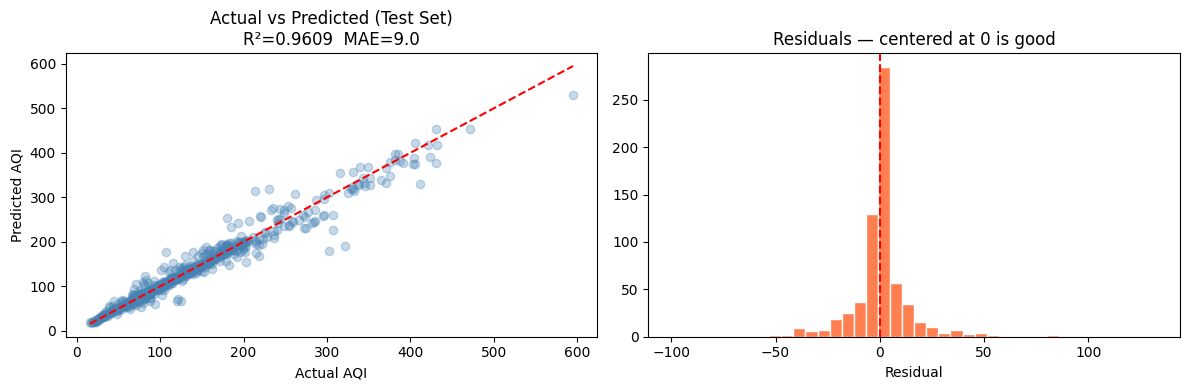

Test R²  : 0.9609
Test MAE : 8.95


In [12]:
best_reg_tuned.fit(X_train, y_reg_train)
y_reg_pred = best_reg_tuned.predict(X_test)

test_r2  = r2_score(y_reg_test, y_reg_pred)
test_mae = mean_absolute_error(y_reg_test, y_reg_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, color='steelblue')
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()], 'r--')
axes[0].set(xlabel='Actual AQI', ylabel='Predicted AQI',
            title=f'Actual vs Predicted (Test Set)\nR²={test_r2:.4f}  MAE={test_mae:.1f}')

axes[1].hist(y_reg_test - y_reg_pred, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set(xlabel='Residual', title='Residuals — centered at 0 is good')

plt.tight_layout()
plt.show()
print(f'Test R²  : {test_r2:.4f}')
print(f'Test MAE : {test_mae:.2f}')

## 14. Feature Importance + SHAP

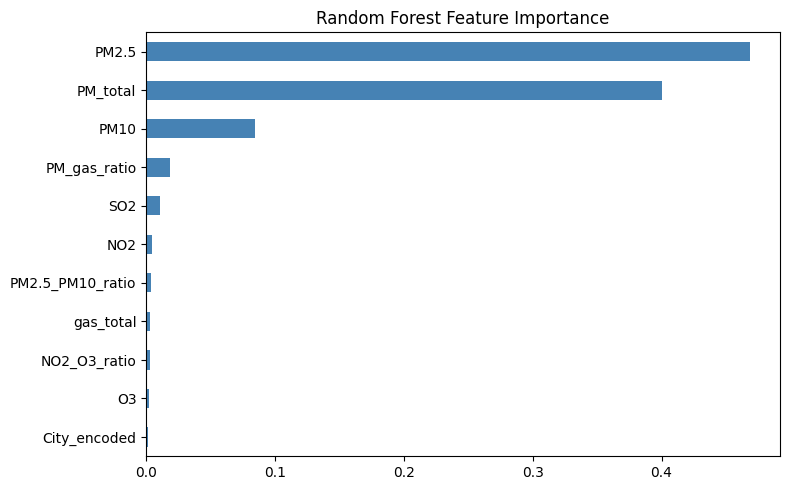

Computing SHAP values...


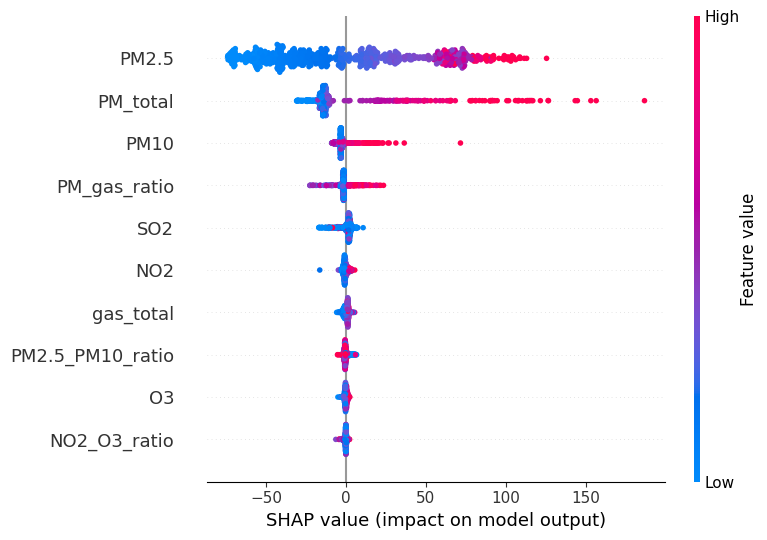

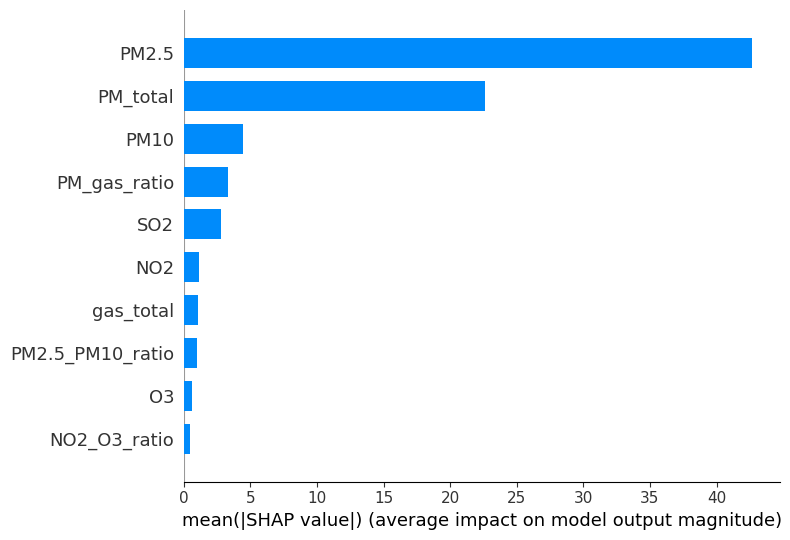

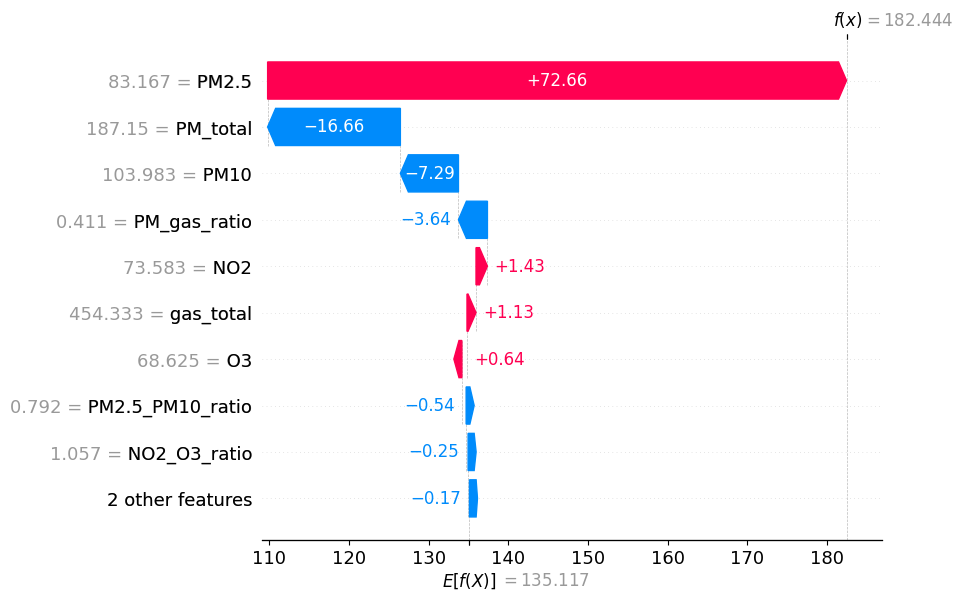

Actual AQI    : 177
Predicted AQI : 182


In [13]:
if hasattr(best_reg_tuned, 'feature_importances_'):
    pd.Series(
        best_reg_tuned.feature_importances_, index=ALL_FEATURES
    ).sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
    plt.title(f'{best_reg_cv_name} Feature Importance')
    plt.tight_layout()
    plt.show()

print('Computing SHAP values...')
explainer   = shap.TreeExplainer(best_reg_tuned)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, max_display=10)
plt.show()

shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=10)
plt.show()

idx = 0
shap.waterfall_plot(shap_values[idx])
plt.show()
print(f'Actual AQI    : {y_reg_test.iloc[idx]:.0f}')
print(f'Predicted AQI : {y_reg_pred[idx]:.0f}')

# CLASSIFICATION PIPELINE
## 15. Define Classification Models

In [14]:
clf_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.05,
        verbosity=0, eval_metric='mlogloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        class_weight='balanced', verbose=-1, random_state=42),
}

print('Classification candidates:', list(clf_models.keys()))

Classification candidates: ['Random Forest', 'XGBoost', 'LightGBM']


## 16. Classification CV — Compare All Models First

Same logic as regression: CV all candidates, find the winner,
then tune only the winner in the next step.

In [15]:
print('Running Classification Cross-Validation on all models...\n')

cv_clf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_rows = []

for name, model in clf_models.items():
    scores = cross_val_score(
        model, X_train_resampled, y_clf_train_resampled,
        cv=cv_clf, scoring='accuracy', n_jobs=-1
    )
    clf_rows.append({
        'Model'        : name,
        'Mean Accuracy': round(scores.mean(), 4),
        'Std Dev'      : round(scores.std(),  4)
    })
    print(f'{name}: {scores.mean():.4f} (+/- {scores.std():.4f})')

clf_results = pd.DataFrame(clf_rows).sort_values('Mean Accuracy', ascending=False).reset_index(drop=True)

clf_results = pd.concat([
    clf_results,
    pd.DataFrame([{'Model': 'Baseline', 'Mean Accuracy': round(dummy_acc, 4), 'Std Dev': 0.0}])
], ignore_index=True)

print('\nCLASSIFICATION CV RESULTS (best to worst):')
display(clf_results)

# Pick winner
best_clf_cv_name = clf_results[~clf_results['Model'].str.contains('Baseline')].iloc[0]['Model']
print(f'\n→ CV Winner: {best_clf_cv_name}  — this model gets GridSearchCV')

Running Classification Cross-Validation on all models...

Random Forest: 0.9524 (+/- 0.0026)
XGBoost: 0.9489 (+/- 0.0027)
LightGBM: 0.9550 (+/- 0.0043)

CLASSIFICATION CV RESULTS (best to worst):


,Model,Mean Accuracy,Std Dev
0,LightGBM,0.9550,0.0043
1,Random Forest,0.9524,0.0026
2,XGBoost,0.9489,0.0027
3,Baseline,0.0955,0.0000



→ CV Winner: LightGBM  — this model gets GridSearchCV


## 17. Classification GridSearchCV 

In [16]:
print(f'Tuning CV winner: {best_clf_cv_name}\n')

if best_clf_cv_name in ['XGBoost', 'LightGBM']:
    base_clf_tuner = (
        xgb.XGBClassifier(eval_metric='mlogloss', verbosity=0, random_state=42)
        if best_clf_cv_name == 'XGBoost'
        else lgb.LGBMClassifier(class_weight='balanced', verbose=-1, random_state=42)
    )
    param_grid_clf = {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [3, 5, 7],
        'learning_rate'   : [0.01, 0.05, 0.1],
        'subsample'       : [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
elif best_clf_cv_name == 'Random Forest':
    base_clf_tuner = RandomForestClassifier(class_weight='balanced', random_state=42)
    param_grid_clf = {
        'n_estimators'     : [100, 200, 300],
        'max_depth'        : [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }

grid_clf = GridSearchCV(
    base_clf_tuner, param_grid_clf,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, verbose=1
)
grid_clf.fit(X_train_resampled, y_clf_train_resampled)

print(f'\nBest params   : {grid_clf.best_params_}')
print(f'Best CV Acc   : {grid_clf.best_score_:.4f}')

best_clf_tuned = grid_clf.best_estimator_
# Add tuned model back for ensemble
clf_models[f'{best_clf_cv_name} (Tuned)'] = best_clf_tuned
print(f'\nFinal classification model ready: {best_clf_cv_name} (tuned)')

Tuning CV winner: LightGBM

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best params   : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV Acc   : 0.9547

Final classification model ready: LightGBM (tuned)


## 18. Soft Voting Ensemble

Built using the tuned winner + the other two base models.
All 3 models vote with probability weights — reduces individual errors.

In [17]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=42)),
        ('xgb', xgb.XGBClassifier(
            n_estimators=200, learning_rate=0.05,
            verbosity=0, eval_metric='mlogloss', random_state=42)),
        ('lgb', lgb.LGBMClassifier(
            n_estimators=200, learning_rate=0.05,
            class_weight='balanced', verbose=-1, random_state=42))
    ],
    voting='soft'
)
clf_models['Voting Ensemble'] = voting_clf

# Quick CV check on ensemble too
ens_scores = cross_val_score(
    voting_clf, X_train_resampled, y_clf_train_resampled,
    cv=cv_clf, scoring='accuracy', n_jobs=-1
)
print(f'Voting Ensemble CV: {ens_scores.mean():.4f} (+/- {ens_scores.std():.4f})')

# Decide final model: tuned winner vs ensemble
tuned_scores = cross_val_score(
    best_clf_tuned, X_train_resampled, y_clf_train_resampled,
    cv=cv_clf, scoring='accuracy', n_jobs=-1
)
print(f'{best_clf_cv_name} (Tuned) CV: {tuned_scores.mean():.4f} (+/- {tuned_scores.std():.4f})')

if ens_scores.mean() >= tuned_scores.mean():
    final_clf      = voting_clf
    final_clf_name = 'Voting Ensemble'
else:
    final_clf      = best_clf_tuned
    final_clf_name = f'{best_clf_cv_name} (Tuned)'

print(f'\n→ Final classifier chosen: {final_clf_name}')

Voting Ensemble CV: 0.9547 (+/- 0.0028)
LightGBM (Tuned) CV: 0.9547 (+/- 0.0024)

→ Final classifier chosen: Voting Ensemble


## 19. Classification Diagnostics — Held-Out Test Set

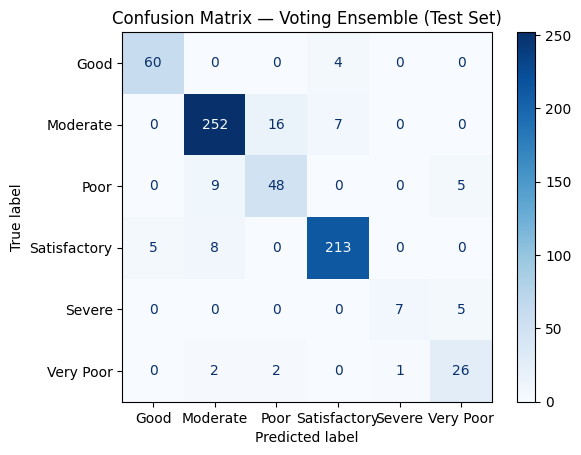


Classification Report — Voting Ensemble (Test Set):

              precision    recall  f1-score   support

        Good       0.92      0.94      0.93        64
    Moderate       0.93      0.92      0.92       275
        Poor       0.73      0.77      0.75        62
Satisfactory       0.95      0.94      0.95       226
      Severe       0.88      0.58      0.70        12
   Very Poor       0.72      0.84      0.78        31

    accuracy                           0.90       670
   macro avg       0.85      0.83      0.84       670
weighted avg       0.91      0.90      0.90       670



In [18]:
final_clf.fit(X_train_resampled, y_clf_train_resampled)
y_clf_pred = final_clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_clf_test, y_clf_pred,
    display_labels=le.classes_,
    cmap='Blues'
)
plt.title(f'Confusion Matrix — {final_clf_name} (Test Set)')
plt.show()

print(f'\nClassification Report — {final_clf_name} (Test Set):\n')
print(classification_report(y_clf_test, y_clf_pred, target_names=le.classes_))

## 20. Results Comparison Plot

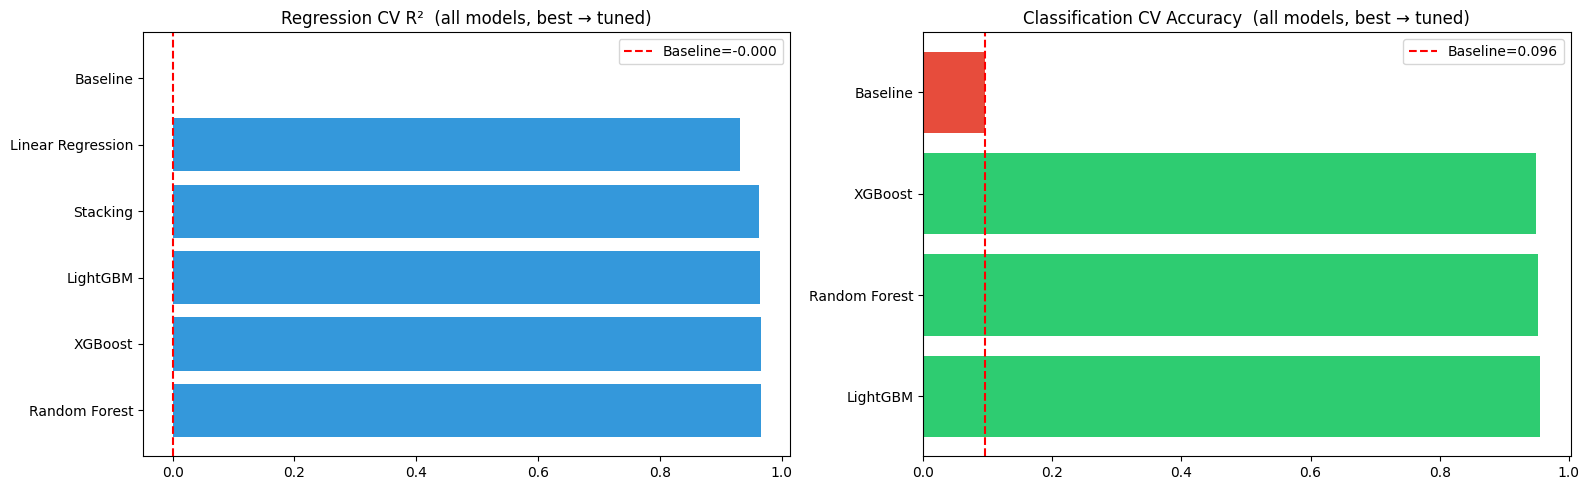

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_reg = ['#e74c3c' if 'Baseline' in m else '#3498db' for m in reg_results['Model']]
axes[0].barh(reg_results['Model'], reg_results['Mean R²'], color=colors_reg)
axes[0].axvline(dummy_r2, color='red', linestyle='--', label=f'Baseline={dummy_r2:.3f}')
axes[0].set_title('Regression CV R²  (all models, best → tuned)')
axes[0].legend()

colors_clf = ['#e74c3c' if 'Baseline' in m else '#2ecc71' for m in clf_results['Model']]
axes[1].barh(clf_results['Model'], clf_results['Mean Accuracy'], color=colors_clf)
axes[1].axvline(dummy_acc, color='red', linestyle='--', label=f'Baseline={dummy_acc:.3f}')
axes[1].set_title('Classification CV Accuracy  (all models, best → tuned)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 21. Final Summary

In [21]:
best_cv_r2  = reg_results[~reg_results['Model'].str.contains('Baseline')]['Mean R²'].max()
best_cv_acc = clf_results[~clf_results['Model'].str.contains('Baseline')]['Mean Accuracy'].max()

final_r2  = r2_score(y_reg_test, y_reg_pred)
final_acc = (y_clf_pred == y_clf_test).mean()

print('=' * 65)
print('  FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'  REGRESSION')
print(f'  CV Winner          : {best_reg_cv_name}')
print(f'  Baseline R²        : {dummy_r2:.4f}')
print(f'  Best CV R²         : {best_cv_r2:.4f}')
print(f'  Test Set R²        : {final_r2:.4f}')
print(f'  Test MAE           : {mean_absolute_error(y_reg_test, y_reg_pred):.2f} AQI units')
print()
print(f'  CLASSIFICATION')
print(f'  CV Winner          : {best_clf_cv_name}')
print(f'  Final Model Used   : {final_clf_name}')
print(f'  Baseline Accuracy  : {dummy_acc:.4f}')
print(f'  Best CV Accuracy   : {best_cv_acc:.4f}')
print(f'  Test Set Accuracy  : {final_acc:.4f}')
print()
print(f'  FEATURES: {len(BASE_FEATURES)} raw → {len(ALL_FEATURES)} total')
print('=' * 65)
print()
print('=' * 65)

  FINAL RESULTS SUMMARY
  REGRESSION
  CV Winner          : Random Forest
  Baseline R²        : -0.0001
  Best CV R²         : 0.9657
  Test Set R²        : 0.9609
  Test MAE           : 8.95 AQI units

  CLASSIFICATION
  CV Winner          : LightGBM
  Final Model Used   : Voting Ensemble
  Baseline Accuracy  : 0.0955
  Best CV Accuracy   : 0.9550
  Test Set Accuracy  : 0.9045

  FEATURES: 5 raw → 11 total

